

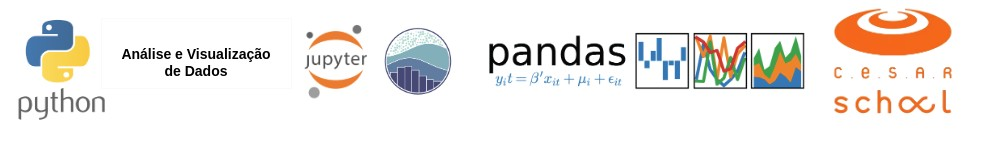



# **Logística/Comercial (compras, vendas e produtos)**

**Professor:** Matheus Soares msl3@cesar.school

**Grupo 05**

**Alunos:**
 
SEVERINO HENRIQUE DE ARAUJO NETO 

MATEUS ALBUQUERQUE FALCAO

LAURA SILVA SOARES DE MELO

THIAGO ROBERTO CAVALCANTI 
            
RAFAEL FERREIRA SALGADO

### **Contexto** 

Uma empresa internacional de comércio eletrônico, com sede em [local omitido], deseja descobrir informações importantes a partir de seu banco de dados de clientes. Para isso, pretende utilizar algumas das técnicas de aprendizado de máquina mais avançadas disponíveis. A empresa vende produtos eletrônicos.



### **Problemática**

1. Perfis de clientes por comportamento de compra
    - Quais grupos de clientes se formam com base em suas características de compra?

2. Padrões de risco de atraso na entrega
    - Existem grupos de pedidos com perfil similar e alto risco de não chegar no prazo?

3. Classificação de produtos por custo e importância
    - Quais grupos de produtos emergem por características de valor e cuidado logístico?

4. Perfis de insatisfação e retenção
    -  grupos combinam baixa avaliação, muitos contatos e alto desconto aplicado?

5. Grupos de operação logística por modal e armazém
    -  combinações de armazém e modal criam padrões distintos de custo e desempenho?


### Bibliotecas

In [1]:
# 📥 Importação das Bibliotecas
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import webbrowser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score
from IPython.display import display
import plotly.graph_objects as go
from plotly.subplots import make_subplots



# Configuração para exibir melhor os dados
pd.set_option('display.float_format', '{:.2f}'.format)

### Exploração dos Dados

In [2]:
#Carregar dataset
path = "C:/Users/melos/OneDrive - Claro SA/LAURA SILVA SOARES DE MELO/eng._e_ analise_de_dados/06_modelos_descritivo/base/Train.csv"
df = pd.read_csv(path, encoding='latin-1')
df.head(10) 


,ï»¿ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [3]:
# Informações das varáveis do datset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ï»¿ID                10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [4]:
df.describe()

,ï»¿ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,5500.00,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,3175.28,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,2750.50,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,5500.00,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,8249.50,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,10999.00,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


----------------------------------------------------------------------------------------------------------------------------------------------------------------

### Análise Exploratória Simples


In [5]:
# valores calculados
desc = df.groupby("Reached.on.Time_Y.N")["Discount_offered"].mean()
peso = df.groupby("Reached.on.Time_Y.N")["Weight_in_gms"].mean()
sac  = df.groupby("Reached.on.Time_Y.N")["Customer_care_calls"].mean()

ordem      = ["low", "medium", "high"]
labels     = ["Low", "Medium", "High"]
valores_imp = [df[df["Product_importance"] == imp]["Reached.on.Time_Y.N"].mean() for imp in ordem]

COR_PRAZO    = "#1D9E75"
COR_ATRASADO = "#D85A30"
COR_ROXO     = "#534AB7"
COR_CINZA    = "#888780"

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        "Desconto médio oferecido",
        "Peso médio (gramas)",
        "Ligações ao SAC (média)",
        "Taxa no prazo por importância"
    ],
    vertical_spacing=0.22,
    horizontal_spacing=0.12
)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[desc[1], desc[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{desc[1]:.1f}%", f"{desc[0]:.1f}%"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[peso[1], peso[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{peso[1]:,.0f}g", f"{peso[0]:,.0f}g"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=1, col=2)

fig.add_trace(go.Bar(
    x=["No prazo", "Atrasado"], y=[sac[1], sac[0]],
    marker_color=[COR_PRAZO, COR_ATRASADO],
    text=[f"{sac[1]:.1f}", f"{sac[0]:.1f}"],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Bar(
    x=labels, y=valores_imp,
    marker_color=[COR_ROXO, COR_CINZA, COR_CINZA],
    text=[f"{v:.0%}" for v in valores_imp],
    textposition="outside", textfont=dict(size=13),
    showlegend=False
), row=2, col=2)

fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="#1a1a1a",
    plot_bgcolor="#2a2a2a",
    title=dict(text="Análise Exploratória", font=dict(size=18)),
    height=650,
    margin=dict(t=80, b=40, l=40, r=40)
)

fig.update_traces(marker_line_width=0)
fig.update_xaxes(showgrid=False)
fig.update_yaxes(gridcolor="#444")

fig.show()

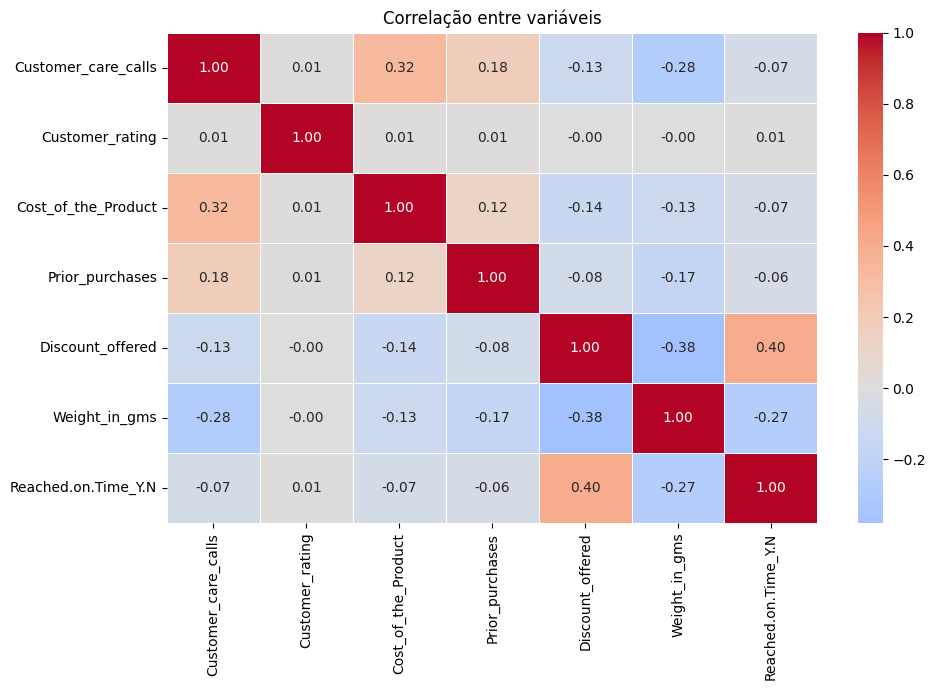

In [6]:
cols_corr = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
             "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]

corr = df[cols_corr].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlação entre variáveis")
plt.tight_layout()
plt.savefig("correlacao.png", dpi=150)
plt.show()

Em Discount_offered tem a correlação mais forte -> Pedidos com desconto maior chegam mais no prazo.

Em Weight_in_gms-> pedidos mais pesados chegam menos no prazo. Faz sentido logístico.

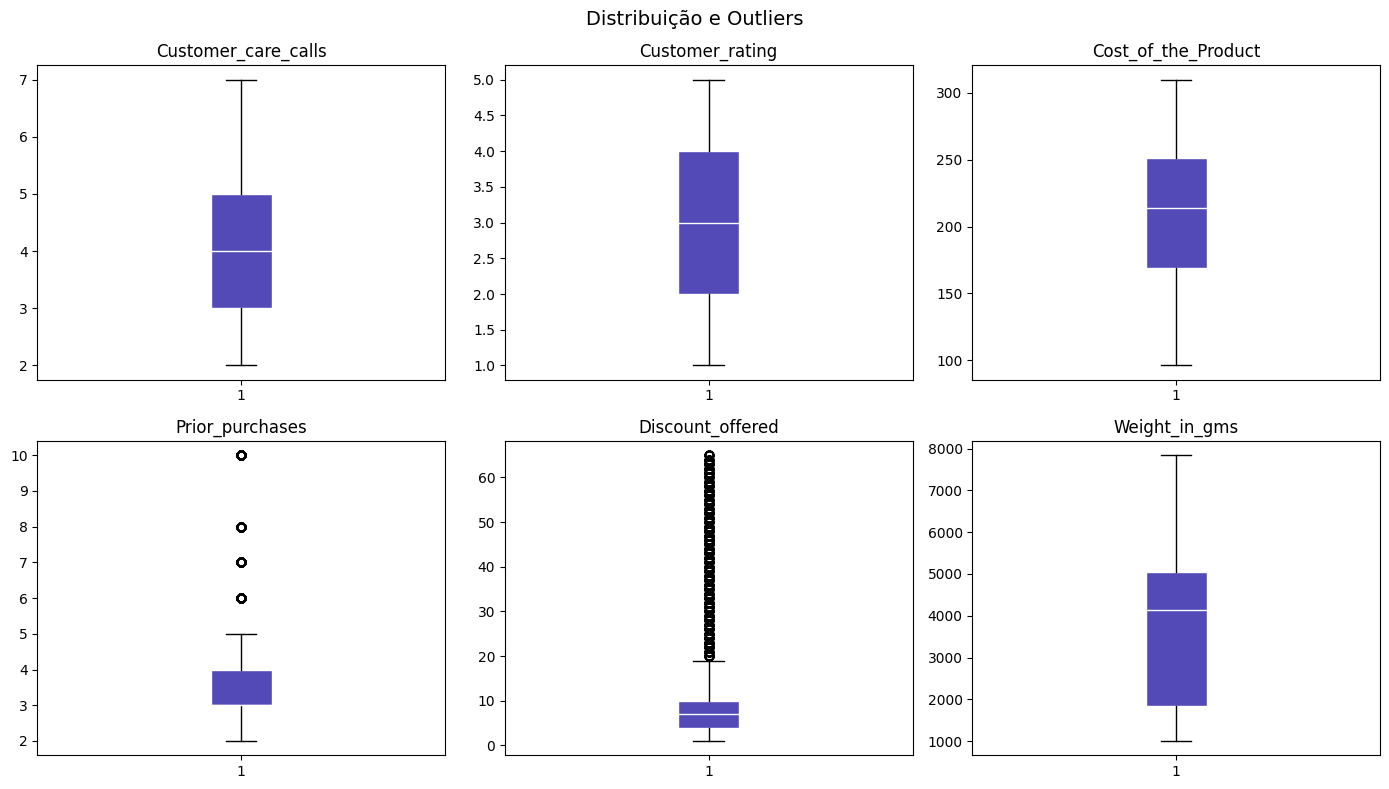

In [7]:
cols_box = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms"]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, col in enumerate(cols_box):
    axs[i].boxplot(df[col], patch_artist=True,
                   boxprops=dict(facecolor="#534AB7", color="white"),
                   medianprops=dict(color="white"))
    axs[i].set_title(col)

plt.suptitle("Distribuição e Outliers", fontsize=14)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()

Customer_care_calls — a maioria liga entre 3 e 5 vezes. Sem outliers.

Customer_rating — notas bem distribuídas de 1 a 5, mediana no 3. Sem outliers.

Cost_of_the_Product — maioria dos produtos entre R$150 e R$250. Sem outliers.

Prior_purchases — maioria comprou 3 a 4 vezes. Poucos clientes com 6 a 10 compras aparecem como outliers.

Discount_offered — o mais irregular. Maioria recebe até 10% de desconto, mas existem muitos casos com até 65% — os outliers mais relevantes do dataset.

Weight_in_gms — produtos variam muito de peso (1.000g a 7.800g). Sem outliers.

-----------------------------------------------------------------

### Tratamento dos Dados

In [8]:
# RENOMEAR COLUNAS PROBLEMÁTICAS
df = df.rename(columns={df.columns[0]: "ID"})
# REMOVER ID
df = df.drop(columns=["ID"])

In [9]:
# Encoding 
# Tem como Objetivo transformar texto em número

df["Gender"]           = df["Gender"].map({"F": 0, "M": 1})
df["Warehouse_block"]  = df["Warehouse_block"].map({"A": 0, "B": 1, "C": 2, "D": 3, "F": 4})
df["Mode_of_Shipment"] = df["Mode_of_Shipment"].map({"Flight": 0, "Road": 1, "Ship": 2})
df["Product_importance"] = df["Product_importance"].map({"low": 0, "medium": 1, "high": 2})


In [10]:
# Separar a variável alvo antes de normalizar
target   = df["Reached.on.Time_Y.N"]
features = df.drop(columns=["Reached.on.Time_Y.N"])

In [11]:
# Normalização
# coloca todas as colunas na mesma escala
scaler    = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

print(df_scaled.head())

   Warehouse_block  Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0             0.45             -2.00                -0.05            -0.70   
1             1.12             -2.00                -0.05             1.42   
2            -1.57             -2.00                -1.80            -0.70   
3            -0.89             -2.00                -0.92             0.01   
4            -0.22             -2.00                -1.80            -0.70   

   Cost_of_the_Product  Prior_purchases  Product_importance  Gender  \
0                -0.69            -0.37               -0.94   -0.99   
1                 0.12            -1.03               -0.94    1.01   
2                -0.57             0.28               -0.94    1.01   
3                -0.71             0.28                0.62    1.01   
4                -0.55            -0.37                0.62   -0.99   

   Discount_offered  Weight_in_gms  
0              1.89          -1.47  
1              2.82          -

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Construção dos Clusters
*Apliquem um ou mais algoritmos de clusterização, sempre justificando a escolha do método utilizado.*

### PROBLEMÁTICA 1: Perfis de clientes — K-Means 

Motivo por usar K-Meas: Os dados são organizados e sem anomalias. O K-Means é o mais simples e direto — você fala quantos grupos quer e ele divide os clientes da forma mais equilibrada possível.

In [12]:
cols_1 = ["Customer_care_calls", "Customer_rating", "Prior_purchases", "Discount_offered", "Gender"]
X1 = df_scaled[cols_1]

kmeans1 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_p1"] = kmeans1.fit_predict(X1)

print("P1 - K-Means")
print("Clusters:", sorted(df["cluster_p1"].unique()))
print("Tamanhos:\n", df["cluster_p1"].value_counts())
print("Silhouette:", round(silhouette_score(X1, df["cluster_p1"]), 3))

P1 - K-Means
Clusters: [np.int32(0), np.int32(1), np.int32(2)]
Tamanhos:
 cluster_p1
2    4651
1    4631
0    1717
Name: count, dtype: int64
Silhouette: 0.256


### PROBLEMÁTICA 2: Risco de atraso — DBSCAN

Motivo por usar DBSCAN: Essa problemática tem muitos outliers (pedidos com desconto ou peso fora do padrão). O DBSCAN é o único dos três que consegue ignorar esses pontos estranhos em vez de forçá-los a entrar em algum grupo, o que deixa os clusters mais limpos.

In [13]:
cols_2 = ["Weight_in_gms", "Mode_of_Shipment", "Warehouse_block", "Cost_of_the_Product", "Discount_offered"]
X2 = df_scaled[cols_2]

db2 = DBSCAN(eps=1.0, min_samples=5)
df["cluster_p2"] = db2.fit_predict(X2)

print("\nP2 - DBSCAN")
print("Clusters:", sorted(df["cluster_p2"].unique()))
print("Tamanhos:\n", df["cluster_p2"].value_counts())
mascara2 = df["cluster_p2"] != -1
if mascara2.sum() > 0:
    print("Silhouette:", round(silhouette_score(X2[mascara2], df["cluster_p2"][mascara2]), 3))



P2 - DBSCAN
Clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Tamanhos:
 cluster_p2
 1    7457
 0    1777
 2    1759
-1       6
Name: count, dtype: int64
Silhouette: 0.12


### PROBLEMÁTICA 3: Classificação de produtos — K-Means

Motivo por usar K-Means: Os produtos naturalmente se dividem em grupos claros — barato, médio e caro, por exemplo. O K-Means é perfeito para encontrar esses grupos quando a separação já existe nos dados.

In [14]:
cols_3 = ["Cost_of_the_Product", "Product_importance", "Weight_in_gms", "Discount_offered"]
X3 = df_scaled[cols_3]

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_p3"] = kmeans3.fit_predict(X3)

print("\nP3 - K-Means")
print("Clusters:", sorted(df["cluster_p3"].unique()))
print("Tamanhos:\n", df["cluster_p3"].value_counts())
print("Silhouette:", round(silhouette_score(X3, df["cluster_p3"]), 3))


P3 - K-Means
Clusters: [np.int32(0), np.int32(1), np.int32(2)]
Tamanhos:
 cluster_p3
2    6097
1    2777
0    2125
Name: count, dtype: int64
Silhouette: 0.331


### PROBLEMÁTICA 4: Insatisfação e retenção — Hierárquico

Motivo por usar Hierárquico: Com poucas variáveis, o clustering hierárquico gera um dendrograma — um gráfico de árvore que mostra como os grupos se formam. Isso ajuda a visualizar se os clientes insatisfeitos formam um grupo único ou se existem subgrupos dentro deles, antes de decidir quantos clusters usar.

In [15]:
cols_4 = ["Customer_rating", "Customer_care_calls", "Prior_purchases", "Discount_offered"]
X4 = df_scaled[cols_4]

hier4 = AgglomerativeClustering(n_clusters=3)
df["cluster_p4"] = hier4.fit_predict(X4)

print("\nP4 - Hierárquico")
print("Clusters:", sorted(df["cluster_p4"].unique()))
print("Tamanhos:\n", df["cluster_p4"].value_counts())
print("Silhouette:", round(silhouette_score(X4, df["cluster_p4"]), 3))


P4 - Hierárquico
Clusters: [np.int64(0), np.int64(1), np.int64(2)]
Tamanhos:
 cluster_p4
0    5800
2    3282
1    1917
Name: count, dtype: int64
Silhouette: 0.246


### PROBLEMÁTICA 5: Operação logística — K-Means

Motivo por usar K-Means: As variáveis de armazém e modal já têm grupos bem definidos por natureza. O K-Means encontra esses padrões de forma rápida e o resultado é fácil de interpretar — cada cluster vai representar um perfil típico de operação.

In [16]:
cols_5 = ["Warehouse_block", "Mode_of_Shipment", "Weight_in_gms", "Cost_of_the_Product"]
X5 = df_scaled[cols_5]

kmeans5 = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_p5"] = kmeans5.fit_predict(X5)

print("\nP5 - K-Means")
print("Clusters:", sorted(df["cluster_p5"].unique()))
print("Tamanhos:\n", df["cluster_p5"].value_counts())
print("Silhouette:", round(silhouette_score(X5, df["cluster_p5"]), 3))


P5 - K-Means
Clusters: [np.int32(0), np.int32(1), np.int32(2)]
Tamanhos:
 cluster_p5
1    5159
0    3728
2    2112
Name: count, dtype: int64
Silhouette: 0.255


----------------------------------------------------------------------------------------------------------------------------------------------

### Avaliação dos Clusters
*Utilizem as métricas vistas em aula para analisar a qualidade dos agrupamentos obtidos.*

****A partir de agora, tudo será feito sobre a Problemática 05****

#### Avaliação Interna
*Métricas que avaliam a qualidade do agrupamento usando apenas os dados, sem rótulos verdadeiros*

| Métrica | O que mede | Bom resultado |
|---|---|---|
| **Método do Cotovelo** | Valida se k=3 foi a escolha certa analisando a inércia | Ponto de "dobra" visível na curva |
| **Silhouette Score** | Quão bem cada ponto está no seu próprio cluster vs outros | Próximo de +1 |
| **Davies-Bouldin** | Similaridade média entre cada cluster e seu vizinho mais parecido | Próximo de 0 |

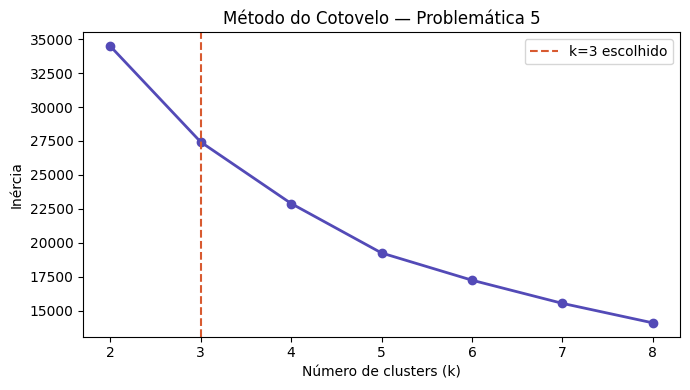

Inércia com k=3: 27,421.9


In [17]:
# 1. MÉTODO DO COTOVELO

inercias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X5)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inercias, marker="o", color="#534AB7", linewidth=2)
plt.axvline(x=3, color="#D85A30", linestyle="--", label="k=3 escolhido")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo — Problemática 5")
plt.legend()
plt.tight_layout()
plt.savefig("cotovelo_p5.png", dpi=150)
plt.show()
print(f"Inércia com k=3: {inercias[1]:,.1f}")


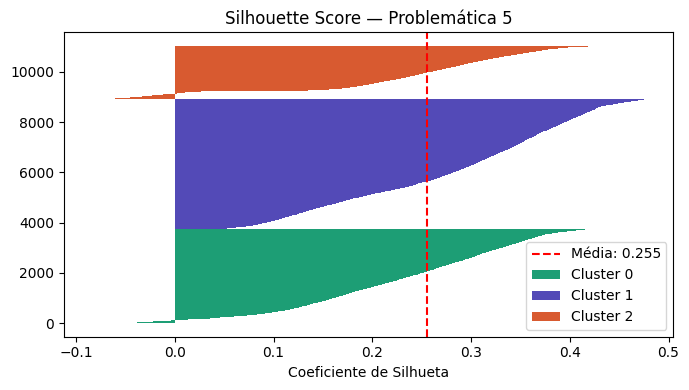

Silhouette Score médio: 0.255


In [18]:
# 2. SILHOUETTE SCORE

sil_score = silhouette_score(X5, df["cluster_p5"])
sil_vals  = silhouette_samples(X5, df["cluster_p5"])

fig, ax = plt.subplots(figsize=(7, 4))
y_lower = 10
cores = ["#1D9E75", "#534AB7", "#D85A30"]

for cluster_id in sorted(df["cluster_p5"].unique()):
    vals = np.sort(sil_vals[df["cluster_p5"] == cluster_id])
    y_upper = y_lower + len(vals)
    ax.barh(range(y_lower, y_upper), vals, height=1.0,
            color=cores[cluster_id], edgecolor="none", label=f"Cluster {cluster_id}")
    y_lower = y_upper + 5

ax.axvline(sil_score, color="red", linestyle="--", label=f"Média: {sil_score:.3f}")
ax.set_xlabel("Coeficiente de Silhueta")
ax.set_title("Silhouette Score — Problemática 5")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("silhouette_p5.png", dpi=150)
plt.show()
print(f"Silhouette Score médio: {sil_score:.3f}")

Davies-Bouldin Index: 1.452  (quanto menor, melhor)


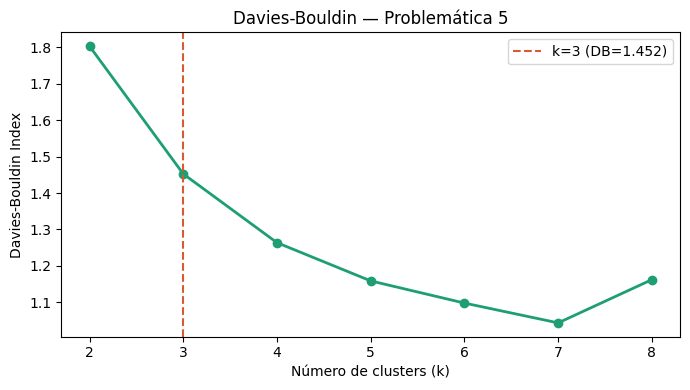

In [19]:
# 3. DAVIES-BOULDIN

db_score = davies_bouldin_score(X5, df["cluster_p5"])
print(f"Davies-Bouldin Index: {db_score:.3f}  (quanto menor, melhor)")

# Comparar DB para diferentes k para contextualizar
db_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X5)
    db_scores.append(davies_bouldin_score(X5, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_range, db_scores, marker="o", color="#1D9E75", linewidth=2)
plt.axvline(x=3, color="#D85A30", linestyle="--", label=f"k=3 (DB={db_score:.3f})")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.title("Davies-Bouldin — Problemática 5")
plt.legend()
plt.tight_layout()
plt.savefig("davies_bouldin_p5.png", dpi=150)
plt.show()


In [20]:
# RESUMO FINAL
print("\n" + "="*45)
print("  RESUMO — Avaliação Interna (Problemática 5)")
print("="*45)
print(f"  MÉTODO DO COTOVELO (k=3)     : {inercias[1]:,.1f}")
print(f"  SILHOUETTE SCORE  : {sil_score:.3f}  (melhor próximo de +1)")
print(f"  DAVIES-BOULDIN    : {db_score:.3f}  (melhor próximo de 0)")
print("="*45)



  RESUMO — Avaliação Interna (Problemática 5)
  MÉTODO DO COTOVELO (k=3)     : 27,421.9
  SILHOUETTE SCORE  : 0.255  (melhor próximo de +1)
  DAVIES-BOULDIN    : 1.452  (melhor próximo de 0)


#### Avaliação Externa
*Métricas que comparam os resultados do agrupamento com rótulos verdadeiros conhecidos*

| Métrica | O que mede | Bom resultado |
|---|---|---|
| **Pureza (Purity)** | Quão "puro" cada cluster é em relação à classe dominante | Próximo de 1 |
| **Índice Rand** | Concordância geral entre os clusters e os rótulos verdadeiros | Próximo de 1 |

In [21]:
# Rótulo verdadeiro

y_true = target.values  # Reached.on.Time_Y.N


In [22]:
# 1. PUREZA (PURITY)
# ────────────────────────────────────────────────────────────────────
def purity_score(y_true, y_pred):
    clusters = np.unique(y_pred)
    total = 0
    detalhes = []
    for c in clusters:
        mask = y_pred == c
        if mask.sum() == 0:
            continue
        classes, counts = np.unique(y_true[mask], return_counts=True)
        dominante = counts.max()
        classe_dom = classes[counts.argmax()]
        total += dominante
        detalhes.append({
            "Cluster": c,
            "Tamanho": mask.sum(),
            "Classe dominante": int(classe_dom),
            "Acertos": dominante,
            "Pureza local": round(dominante / mask.sum(), 3)
        })
    pureza_global = total / len(y_true)
    return pureza_global, detalhes

purity, detalhes = purity_score(y_true, df["cluster_p5"].values)

print("── PUREZA (PURITY) ──────────────────────────────")
import pandas as pd
display(pd.DataFrame(detalhes))
print(f"Pureza Global: {purity:.3f}  (quanto mais próximo de 1, melhor)")

── PUREZA (PURITY) ──────────────────────────────


,Cluster,Tamanho,Classe dominante,Acertos,Pureza local
0,0,3728,1,2856,0.77
1,1,5159,0,2757,0.53
2,2,2112,1,1305,0.62


Pureza Global: 0.629  (quanto mais próximo de 1, melhor)


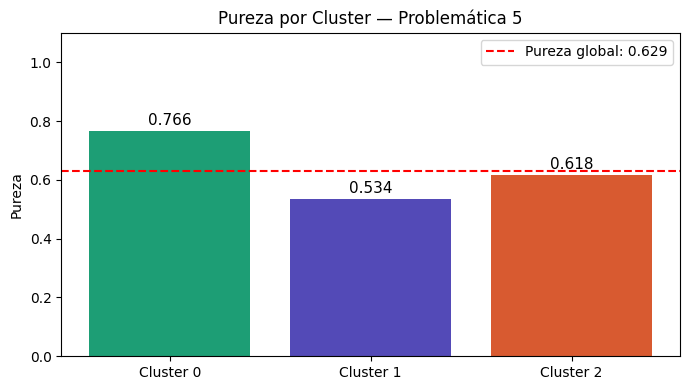

In [23]:
# Gráfico de pureza por cluster
fig, ax = plt.subplots(figsize=(7, 4))
clusters_ids = [d["Cluster"] for d in detalhes]
pureza_local = [d["Pureza local"] for d in detalhes]
cores = ["#1D9E75", "#534AB7", "#D85A30"]
bars = ax.bar([f"Cluster {c}" for c in clusters_ids], pureza_local,
              color=cores[:len(clusters_ids)], edgecolor="none")
ax.axhline(purity, color="red", linestyle="--", label=f"Pureza global: {purity:.3f}")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Pureza")
ax.set_title("Pureza por Cluster — Problemática 5")
ax.legend()
for bar, val in zip(bars, pureza_local):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
            ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("purity_p5.png", dpi=150)
plt.show()


── ÍNDICE RAND (AJUSTADO) ───────────────────────
Adjusted Rand Index (ARI): 0.043
  > 0.5  → boa concordância
  ~ 0    → concordância aleatória
  < 0    → pior que aleatório


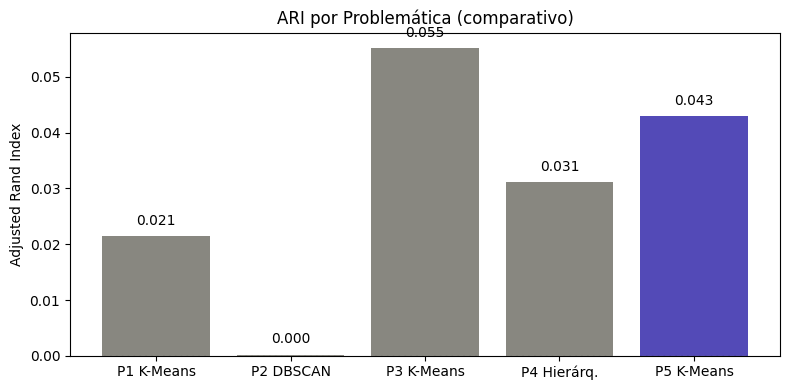

In [24]:
#  2. ÍNDICE RAND (AJUSTADO)
ari = adjusted_rand_score(y_true, df["cluster_p5"].values)

print("── ÍNDICE RAND (AJUSTADO) ───────────────────────")
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print("  > 0.5  → boa concordância")
print("  ~ 0    → concordância aleatória")
print("  < 0    → pior que aleatório")

# Comparar ARI entre as 5 problemáticas para contextualizar
aris = {
    "P1 K-Means":    adjusted_rand_score(y_true, df["cluster_p1"].values),
    "P2 DBSCAN":     adjusted_rand_score(y_true, df["cluster_p2"].values),
    "P3 K-Means":    adjusted_rand_score(y_true, df["cluster_p3"].values),
    "P4 Hierárq.":   adjusted_rand_score(y_true, df["cluster_p4"].values),
    "P5 K-Means":    ari,
}

fig, ax = plt.subplots(figsize=(8, 4))
cores_ari = ["#888780"] * 4 + ["#534AB7"]
bars = ax.bar(aris.keys(), aris.values(), color=cores_ari, edgecolor="none")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("ARI por Problemática (comparativo)")
for bar, val in zip(bars, aris.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.002 if val >= 0 else val - 0.008,
            f"{val:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("ari_comparativo.png", dpi=150)
plt.show()



In [25]:
# RESUMO FINAL
print("=" * 45)
print("  RESUMO — Avaliação Externa (Problemática 5)")
print("=" * 45)
print(f"  Pureza Global         : {purity:.3f}  (próximo de 1 = melhor)")
print(f"  Adjusted Rand Index   : {ari:.3f}  (próximo de 1 = melhor)")
print("=" * 45)

  RESUMO — Avaliação Externa (Problemática 5)
  Pureza Global         : 0.629  (próximo de 1 = melhor)
  Adjusted Rand Index   : 0.043  (próximo de 1 = melhor)


----------------------------------------------------------------------------------------------------------------------------------------------

### Descrição detalhada de cada cluster 
*Expliquem o perfil de cada grupo encontrado, destacando características,diferenças e possíveis interpretações*

In [26]:

caminho = os.path.abspath("estudo_problematica5.html")
webbrowser.open(f"file:///C:/Users/melos/OneDrive%20-%20Claro%20SA/LAURA%20SILVA%20SOARES%20DE%20MELO/eng._e_%20analise_de_dados/06_modelos_descritivo/estudo_problematica5.html")

True